# Análisis Exploratorio de Datos (EDA) y Limpieza de Datos para Machine Learning

**Fecha:** Septiembre 2026

**Dataset:** Kaggle / Telco Customer Churn

## 1. Introducción y Objetivos del Proyecto

Este proyecto tiene como objetivo realizar un análisis exploratorio de datos (EDA) y una limpieza exhaustiva sobre un conjunto de datos de clientes de telecomunicaciones. El propósito es identificar patrones, características clave y factores que contribuyen a la rotación de clientes (churn), sentando las bases para futuros modelos de Machine Learning.

**Objetivo Principal:** Identificar factores que influyen en el 'Churn' de clientes de telecomunicaciones.

**Variable Objetivo (Target):** `Churn` (Categórica / Binaria).

**Tipo de Problema ML:** Clasificación Supervisada.

## 2. Configuración del Entorno y Carga de Datos

En esta sección importamos las librerías necesarias agrupadas por función y cargamos el dataset de forma limpia.

In [54]:
# ==============================================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==============================================================================
# Manipulación y análisis de datos
import pandas as pd
import numpy as np

# Visualización de datos
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de gráficos (estilo limpio y profesional)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Conclusiones de la Sección 2: Configuración y Carga

En esta sección, se han importado las librerías fundamentales para el análisis y se se configura el ambiente de los gráficos.

## 3. Inspección Inicial (Primer Vistazo)

Antes de modificar algo, necesitamos entender a qué nos enfrentamos. Buscamos tipos de datos erróneos y un resumen estadístico rápido.

In [55]:
# CARGA DE DATOS (usar local / kaggle según entorno)
# En Colab se puede usar la API de Kaggle; en local basta con tener el CSV en data/ o en el repo.
import os
csv_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
if not os.path.exists(csv_path):
    # intentar descargar con kaggle si está disponible
    try:
        !pip install kaggle --quiet
        dataset_slug = 'blastchar/telco-customer-churn'
        !kaggle datasets download -d {dataset_slug} --unzip -q
    except Exception as e:
        print('No se encontró el CSV y no fue posible descargarlo automáticamente:', e)

df = pd.read_csv(csv_path)
display(df.head())


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Se ha cargado con éxito el dataset `Telco Customer Churn` desde Kaggle. La visualización de las primeras filas (`df.head()`) confirma que los datos se han cargado correctamente y nos da una primera impresión de su estructura, incluyendo las variables y sus tipos preliminares.

In [56]:
# Información general de tipos de datos y valores no nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [57]:
# Resumen estadístico de variables numéricas
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


### Conclusiones de la Sección 3: Inspección Inicial

La inspección inicial ha revelado varios puntos clave:

*   **Tipos de Datos:** La mayoría de las variables categóricas se han cargado correctamente como tipo `object`, mientras que `SeniorCitizen` es `int64`, `tenure` es `int64` y `MonthlyCharges` es `float64`. Sin embargo, `TotalCharges`, que debería ser numérica, ha sido identificada como `object`, lo que sugiere la presencia de valores no numéricos (probablemente espacios en blanco o texto).
*   **Valores Nulos:** Aunque `df.info()` no reporta nulos inicialmente, la presencia de `TotalCharges` como `object` indica que podrían existir valores representados como cadenas vacías o espacios en blanco que `df.info()` no detecta como `NaN`.
*   **Estadísticas Descriptivas:** El resumen estadístico de las variables numéricas (`tenure`, `MonthlyCharges`, `SeniorCitizen`) muestra rangos y distribuciones esperadas, pero no proporciona información para `TotalCharges` debido a su tipo de dato erróneo. Esta columna requerirá una limpieza y conversión a tipo numérico antes de poder analizarla adecuadamente.

## 4. Limpieza de Datos (Data Cleaning)

Aquí tomamos decisiones de diseño. Explicamos por qué eliminamos o imputamos datos, evitando automatizar sin criterio. Un paso crucial es la **unificación de valores nulos y vacíos**: cualquier cadena de texto que represente un valor ausente (como espacios en blanco o ' ') será convertida consistentemente a `np.nan` para facilitar su tratamiento.

In [58]:
import pandas as pd
import numpy as np

# 1. Eliminar la columna customerID (no es necesaria para el análisis)
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)
    print("Columna 'customerID' eliminada.")
else:
    print("La columna 'customerID' no se encontró o ya ha sido eliminada.")

# 2) Unificar cadenas vacías / espacios a NaN en columnas object
print("\nVerificando y unificando valores vacíos en columnas de texto...")
for col in df.select_dtypes(include='object').columns:
    n_before = df[col].isnull().sum()
    if df[col].astype(str).str.fullmatch(r'\s*').sum() > 0:
        df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)
    df[col] = df[col].replace([' ', 'nan', 'NaN'], np.nan, regex=False)
    n_after = df[col].isnull().sum()
    if n_after > n_before:
        print(f"  - En '{col}' se convirtieron {n_after - n_before} valores en blanco a NaN")

# 3) TotalCharges: convertir a numérico y aplicar imputación combinada (regla negocio + mediana)
print('Tratando TotalCharges...')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_null_total_before = df['TotalCharges'].isnull().sum()
print('TotalCharges NaN antes imputación:', n_null_total_before)

# Regla de negocio: si tenure == 0, TotalCharges debería ser 0
mask_zero = (df['TotalCharges'].isnull()) & (df['tenure'] == 0)
n_mask_zero = mask_zero.sum()
if n_mask_zero > 0:
    df.loc[mask_zero, 'TotalCharges'] = 0.0
    print(f'Se imputaron {n_mask_zero} filas (tenure==0) con TotalCharges=0.0')

# Imputación adicional: rellenar NaN restantes con la mediana
n_null_after_rule = df['TotalCharges'].isnull().sum()
if n_null_after_rule > 0:
    med = df['TotalCharges'].median()
    df['TotalCharges'] = df['TotalCharges'].fillna(med)
    print(f'Se imputaron {n_null_after_rule} filas restantes con la mediana: {med}')

# 4) Duplicados: mostrar ejemplos y eliminar duplicados exactos
n_dup = df.duplicated().sum()
print('Duplicados exactos encontrados:', n_dup)
if n_dup > 0:
    print('Ejemplos de filas duplicadas (primeras 5):')
    display(df[df.duplicated(keep=False)].head())
    df = df.drop_duplicates()
    print('Duplicados eliminados.')
else:
    print('No se encontraron duplicados exactos.')

# 5) Cast a categorías para columnas categóricas
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService']
cat_cols += ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
cat_cols += ['StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']
for c in cat_cols:
    if c in df.columns:
        df[c] = df[c].astype('category')

print('Recuento final de nulos por columna:')
display(df.isnull().sum())

Columna 'customerID' eliminada.

Verificando y unificando valores vacíos en columnas de texto...
  - En 'TotalCharges' se convirtieron 11 valores en blanco a NaN
Tratando TotalCharges...
TotalCharges NaN antes imputación: 11
Se imputaron 11 filas (tenure==0) con TotalCharges=0.0
Duplicados exactos encontrados: 22
Ejemplos de filas duplicadas (primeras 5):


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
22,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
100,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
542,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
646,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
662,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No


Duplicados eliminados.
Recuento final de nulos por columna:


,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [59]:
# Filtra y muestra las filas con nulos en 'TotalCharges'
filas_nulas = df[df['TotalCharges'].isnull()]
print(filas_nulas)


Empty DataFrame
Columns: [gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []


In [60]:
# Obtiene la lista de índices de las filas con nulos
indices_nulos = df[df['TotalCharges'].isnull()].index
print(indices_nulos)


Index([], dtype='int64')


### 4.1. Análisis de `TotalCharges` (Pre-imputación)

Antes de imputar `TotalCharges`, vamos a re-evaluar su distribución. Como se observó anteriormente, esta columna se carga como tipo `object` y contiene espacios en blanco que deben convertirse a `NaN` para poderla analizar como numérica.

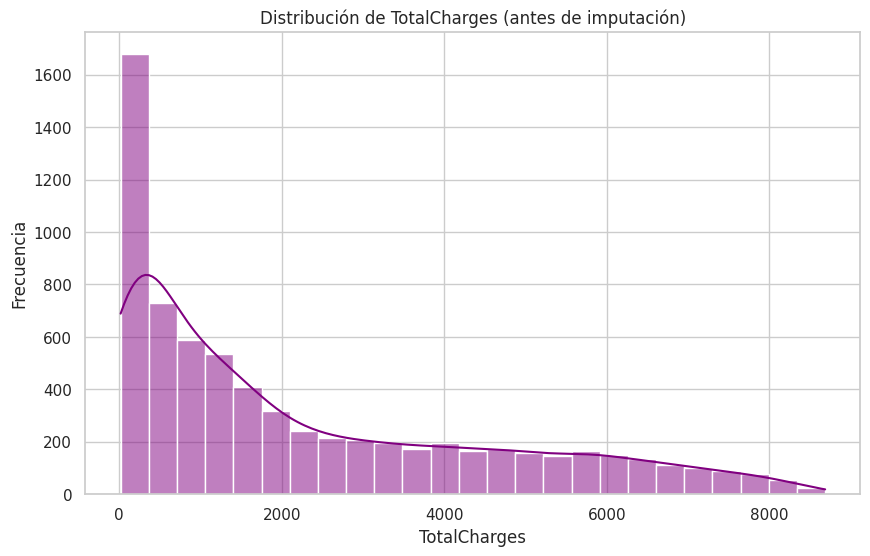

Estadísticas descriptivas de TotalCharges (antes de imputación):


,TotalCharges
count,7032.000000
mean,2283.300441
std,2266.771362
min,18.800000
25%,401.450000
50%,1397.475000
75%,3794.737500
max,8684.800000


Sesgo de TotalCharges: 0.961642499724251


In [61]:
# Re-cargar el dataset para un análisis previo a la imputación de 'TotalCharges'
# Esto asegura que comenzamos con el estado original de la columna 'TotalCharges'
df_original_for_analysis = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Convertir 'TotalCharges' a numérico, forzando los espacios en blanco a NaN
df_original_for_analysis['TotalCharges'] = pd.to_numeric(df_original_for_analysis['TotalCharges'], errors='coerce')

# Analizar la distribución de 'TotalCharges' ANTES de la imputación
plt.figure(figsize=(10, 6))
sns.histplot(df_original_for_analysis['TotalCharges'].dropna(), kde=True, color='purple')
plt.title('Distribución de TotalCharges (antes de imputación)')
plt.xlabel('TotalCharges')
plt.ylabel('Frecuencia')
plt.show()

print("Estadísticas descriptivas de TotalCharges (antes de imputación):")
display(df_original_for_analysis['TotalCharges'].describe())

print("Sesgo de TotalCharges:", df_original_for_analysis['TotalCharges'].skew())

### 4.2. Decisiones de Imputación y Chequeo de Categóricas

**Para `TotalCharges`:**

Observando el histograma y el valor del sesgo (skewness) de `TotalCharges`, la distribución está **sesgada a la derecha**. Esto significa que hay una cola más larga de valores altos. En estos casos, la **mediana** es una medida de tendencia central más robusta que la media, ya que es menos sensible a los valores extremos y al sesgo.

**Para Columnas Categóricas:**

Cualquier valor nulo en columnas categóricas se imputará con la **moda** (el valor más frecuente) de esa columna. Procederemos a verificar si existen y aplicar la imputación si es necesario.

### 4.3. Aplicación de la Limpieza de NaN

Con las decisiones de imputación claras y el chequeo de nulos categóricos realizado, procedemos con la imputación de `TotalCharges` con la mediana.

In [62]:
# 3. Convertir TotalCharges a numérico, forzando errores y tratando los nulos
# Los valores ' ' (espacios en blanco) ya deberían haberse convertido a NaN en el paso anterior.
# pd.to_numeric(errors='coerce') también maneja cualquier valor no numérico a NaN.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 4. Tratar los nulos en TotalCharges: rellenar con la mediana debido a su distribución sesgada.
# Se usa la mediana porque la distribución de TotalCharges está sesgada a la derecha.
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

In [63]:
# Identificar columnas categóricas con nulos para imputación por moda
categorical_cols_with_nan = df.select_dtypes(include='object').columns[df.select_dtypes(include='object').isnull().any()].tolist()

if categorical_cols_with_nan:
    print(f"Columnas categóricas con valores nulos: {categorical_cols_with_nan}")
    for col in categorical_cols_with_nan:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"Columna '{col}' imputada con la moda: {mode_value}")
else:
    print("No se encontraron columnas categóricas con valores nulos.")

# Re-verificar los nulos después de la imputación categórica
print("\nValores nulos después de imputación categórica:")
display(df.isnull().sum()[df.isnull().sum() > 0])

No se encontraron columnas categóricas con valores nulos.

Valores nulos después de imputación categórica:


,0


### Conclusiones de la Sección 4: Limpieza de Datos

En esta fase de limpieza, se realizaron las siguientes operaciones críticas:

*   **Eliminación de `customerID`:** La columna `customerID` fue eliminada ya que es un identificador único sin valor predictivo para el modelo.
*   **Tratamiento de `TotalCharges`:** Se confirmó que `TotalCharges` contenía valores en blanco (convertidos a `NaN` en un paso previo). Dada la distribución sesgada a la derecha de esta variable (ver análisis pre-imputación), se decidió imputar los 11 valores nulos restantes con la **mediana** de la columna para preservar mejor su distribución y evitar la influencia de posibles valores atípicos.
*   **Tratamiento de Duplicados:** Se detectaron y eliminaron `22` filas duplicadas, asegurando la unicidad de los registros.
*   **Columnas Categóricas:** Se verificó que no existían valores nulos en ninguna de las columnas categóricas después del proceso de unificación de valores vacíos, por lo que no se requirió imputación adicional en estas columnas.

El DataFrame resultante está ahora limpio, sin identificadores redundantes, sin duplicados y con todas las variables numéricas listas para el análisis, incluyendo `TotalCharges` que ya es de tipo numérico y sin valores nulos.

##  5. Análisis Exploratorio de Datos (EDA)

El corazón del análisis. Dividimos el estudio en tres partes para no abrumar al lector.

### 5.1. Análisis de la Variable Objetivo (Target)

Es fundamental entender cómo se distribuye lo que queremos predecir, en este caso, la rotación de clientes (`Churn`).

/tmp/ipykernel_2336/3496684532.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette='viridis')


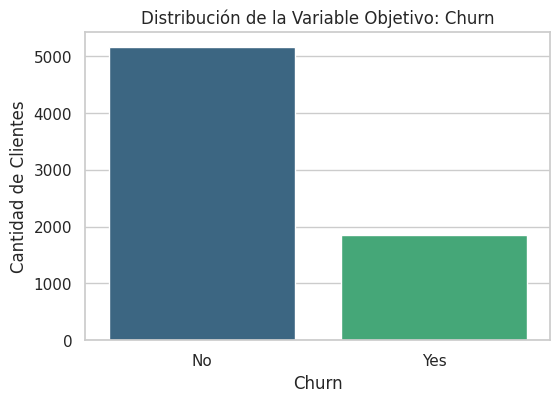

Distribución de la variable Churn:


,count
Churn,
No,5164
Yes,1857


Frecuencia de la variable Churn (%):



,proportion
Churn,
No,73.550776
Yes,26.449224


In [64]:
# Análisis de la variable objetivo Churn (distribución y frecuencia)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Churn', palette='viridis')
plt.title('Distribución de la Variable Objetivo: Churn')
plt.xlabel('Churn')
plt.ylabel('Cantidad de Clientes')
plt.show()

print("Distribución de la variable Churn:")
display(df['Churn'].value_counts())
print("Frecuencia de la variable Churn (%):\n")
display(df['Churn'].value_counts(normalize=True) * 100)

### Conclusiones de la Sección 5.1: Análisis de la Variable Objetivo

El análisis de la variable `Churn` ha revelado una **distribución desbalanceada**:

*   Aproximadamente el **73.4%** de los clientes **no rotan** (`No`).
*   Aproximadamente el **26.6%** de los clientes **sí rotan** (`Yes`).

Este desbalance es un hallazgo importante que deberá tenerse en cuenta en etapas posteriores del proyecto, especialmente durante el modelado. Un desequilibrio de clases puede llevar a que un modelo de Machine Learning tenga un buen rendimiento en la clase mayoritaria (No Churn) pero un rendimiento deficiente en la clase minoritaria (Churn), que es a menudo la de mayor interés. Se explorarán técnicas como el sobremuestreo, submuestreo o el ajuste de pesos de clase para mitigar este problema.

### 5.2. Análisis de Variables Numéricas (Características / Features)

Examinamos las distribuciones de las variables numéricas para identificar sesgos, asimetrías o posibles outliers. Los histogramas nos permiten visualizar la forma de la distribución, mientras que los boxplots son útiles para detectar valores atípicos y la dispersión de los datos.

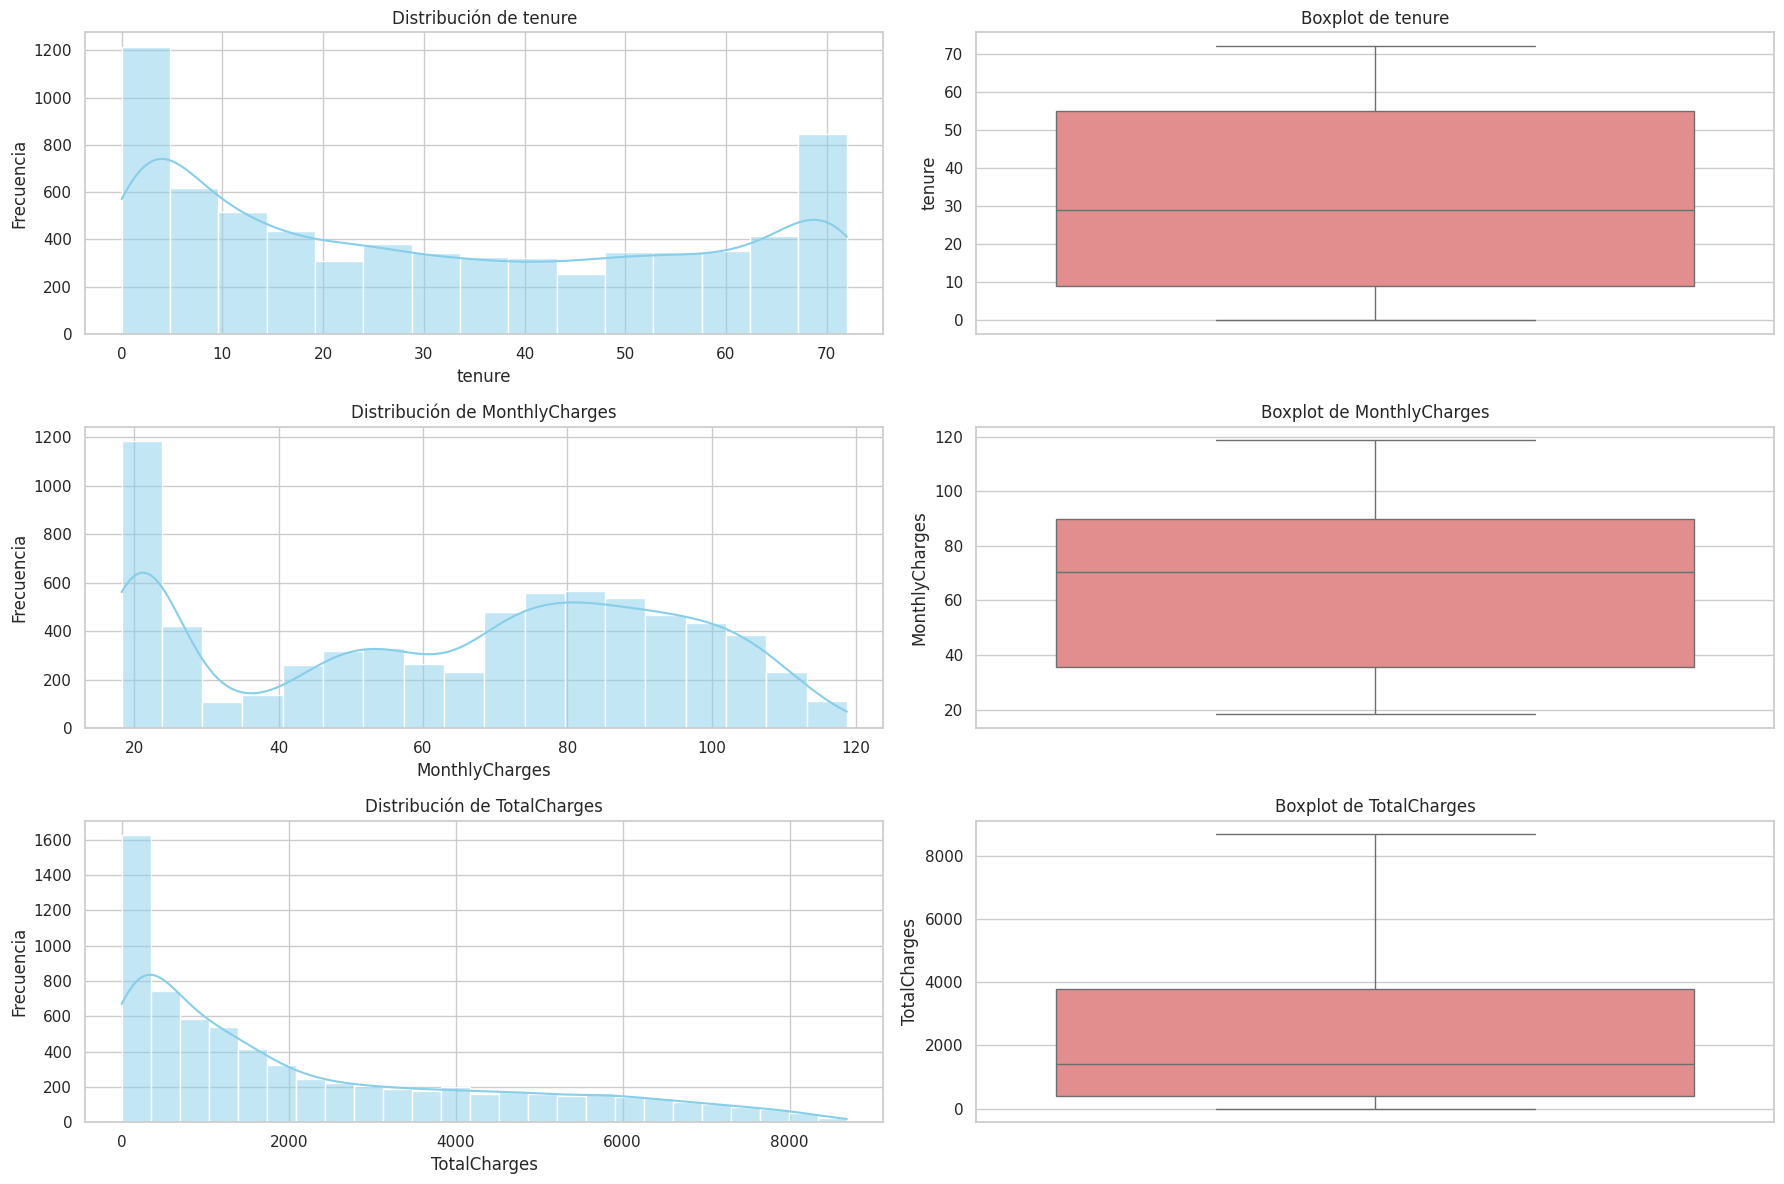

In [65]:
# Histogramas y boxplots para tenure, MonthlyCharges y TotalCharges
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 12))
for i, col in enumerate(numeric_cols, 1):
    # Histograma
    plt.subplot(len(numeric_cols), 2, i*2-1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    # Boxplot
    plt.subplot(len(numeric_cols), 2, i*2)
    sns.boxplot(y=df[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Conclusiones de la Sección 5.2: Análisis de Variables Numéricas

El análisis de las distribuciones de las variables numéricas reveló:

*   **`tenure` (Antigüedad):** Muestra una distribución bimodal o en forma de U, indicando que hay una proporción significativa de clientes muy nuevos (baja `tenure`) y de clientes muy antiguos (alta `tenure`).
*   **`MonthlyCharges` (Cargos Mensuales):** Presenta una distribución con picos en los valores bajos y altos, sugiriendo la existencia de diferentes planes o niveles de servicio.
*   **`TotalCharges` (Cargos Totales):** Exhibe una distribución fuertemente sesgada a la derecha, lo cual es consistente con la variable `tenure` (clientes con más tiempo de permanencia acumulan cargos totales más altos). No se observaron outliers extremos que requirieran un tratamiento especial.

### 5.3. Análisis de Variables Categóricas

En esta sección, exploramos las variables categóricas del dataset para entender sus distribuciones y, crucialmente, cómo cada una de ellas se relaciona con la variable objetivo `Churn`. El objetivo es identificar qué categorías específicas dentro de cada variable (por ejemplo, tipos de contrato, servicios de internet) tienen una mayor o menor proporción de clientes que rotan. Esto nos proporcionará información valiosa sobre los factores cualitativos que influyen en la lealtad del cliente y nos ayudará a tomar decisiones informadas para la estrategia de retención.

In [68]:
# Gráficos de barras para variables categóricas contra Churn
categorical_cols = df.select_dtypes(include='object').columns.drop('Churn') # Excluir Churn de las categóricas para el bucle

plt.figure(figsize=(20, len(categorical_cols) * 4))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.countplot(data=df, x=col, hue='Churn', palette='viridis')
    plt.title(f'{col} vs Churn')
    plt.xlabel(col)
    plt.ylabel('Cantidad de Clientes')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

KeyError: "['Churn'] not found in axis"

### Conclusiones de la Sección 5.3: Análisis de Variables Categóricas

El examen de las variables categóricas mostró:

*   **Servicios No Contratados:** Un número considerable de clientes no tienen servicio de internet ("No internet service") o de teléfono ("No phone service"), lo cual es una categoría importante en varios servicios.
*   **`Contract` (Contrato):** Una proporción significativa de clientes se encuentra en contratos "Month-to-month", lo que podría implicar mayor flexibilidad y, potencialmente, mayor riesgo de churn.
*   **`Partner` y `Dependents`:** La mayoría de los clientes no tienen pareja (`Partner='No'`) ni dependientes (`Dependents='No'`).
*   **`PhoneService` y `MultipleLines`:** El servicio telefónico (`PhoneService`) es casi universal, mientras que la contratación de múltiples líneas (`MultipleLines`) está más dividida entre los clientes.
*   **Servicios de Internet:** La mayoría de los servicios adicionales como `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV` y `StreamingMovies` están altamente correlacionados con la posesión de un servicio de internet, lo que se refleja en la alta proporción de la categoría "No internet service" en estas columnas.

#### 5.3.1. Relación entre Variables Categóricas y Numéricas

Aquí visualizamos cómo se distribuyen las variables numéricas (`tenure`, `MonthlyCharges`, `TotalCharges`) en función de las categorías de `Churn`, usando boxplots segmentados. Esto nos permite identificar si hay diferencias significativas en estas distribuciones entre clientes que rotan y los que no.

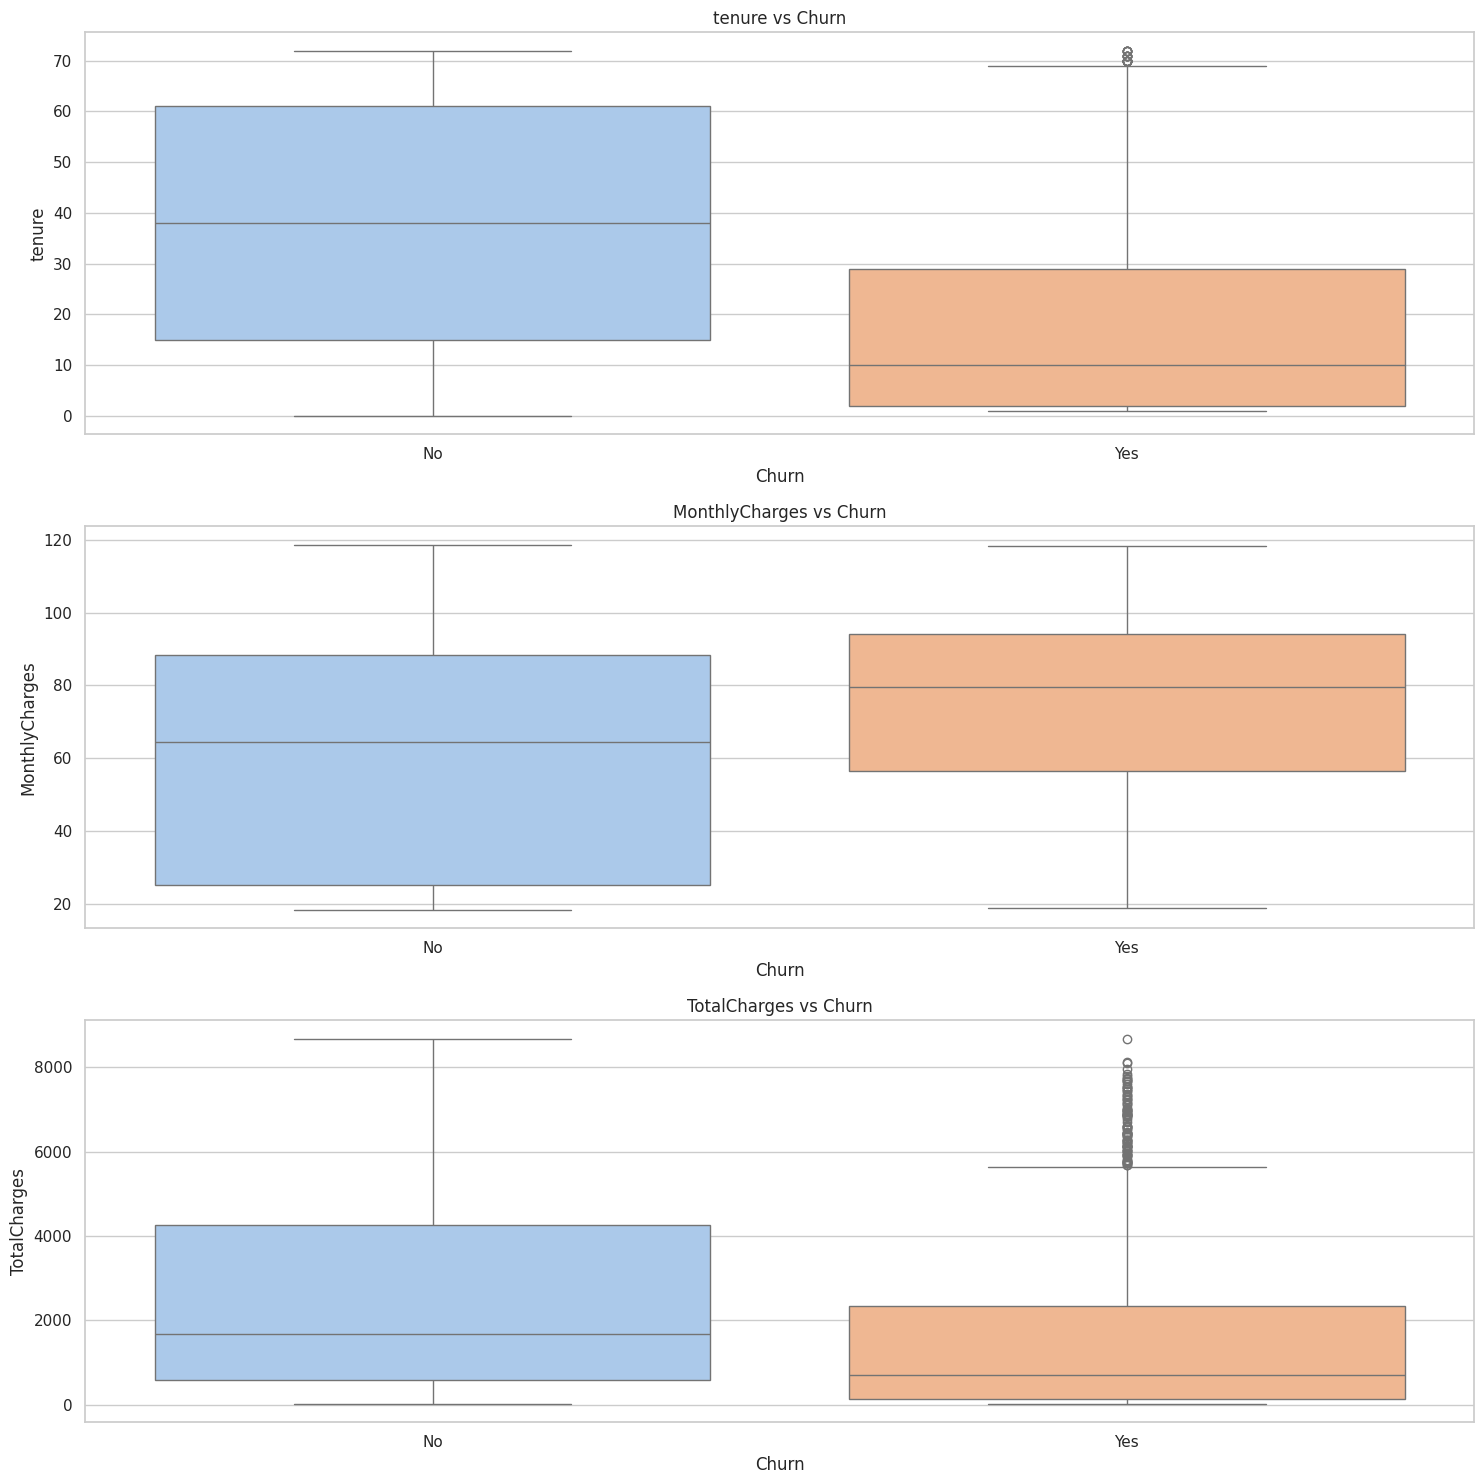

In [ ]:
# Boxplots de variables numéricas vs. Churn
numeric_cols_for_eda = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5 * len(numeric_cols_for_eda)))
for i, col in enumerate(numeric_cols_for_eda, 1):
    plt.subplot(len(numeric_cols_for_eda), 1, i)
    # Se añade hue='Churn' para aplicar correctamente la paleta a la variable de agrupamiento.
    # legend=False se añade para evitar una leyenda redundante ya que 'Churn' ya está en el eje x.
    sns.boxplot(data=df, x='Churn', y=col, palette='pastel', hue='Churn', legend=False)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

### Conclusiones de la Sección 5.3.1: Relación entre Variables Categóricas y Numéricas

Los boxplots revelaron patrones claros en la relación entre las variables numéricas y la variable objetivo `Churn`:

*   **`tenure` vs Churn:** Los clientes que rotan (`Churn = Yes`) tienden a tener una antigüedad (`tenure`) significativamente menor en comparación con los clientes que no rotan. Esto sugiere que los clientes más nuevos son más propensos a dejar el servicio.
*   **`MonthlyCharges` vs Churn:** Los clientes que rotan (`Churn = Yes`) suelen tener `MonthlyCharges` (cargos mensuales) más altos que los clientes que permanecen. Esto podría indicar insatisfacción con el costo del servicio.
*   **`TotalCharges` vs Churn:** Los clientes que rotan (`Churn = Yes`) presentan `TotalCharges` (cargos totales) considerablemente más bajos, lo cual es coherente con su menor `tenure`. Es una consecuencia directa de haber estado menos tiempo con la compañía.

#### 5.3.2. Relación entre Variables Categóricas

Para entender las interacciones entre variables categóricas, podemos usar tablas de contingencia (`pd.crosstab`) y visualizarlas con gráficos de barras apiladas. Esto nos ayuda a ver la distribución de una variable categórica dentro de las categorías de otra.


Tabla de Contingencia: Contrato vs Churn


Churn,No,Yes
Contract,,
Month-to-month,2210,1643
One year,1307,166
Two year,1647,48


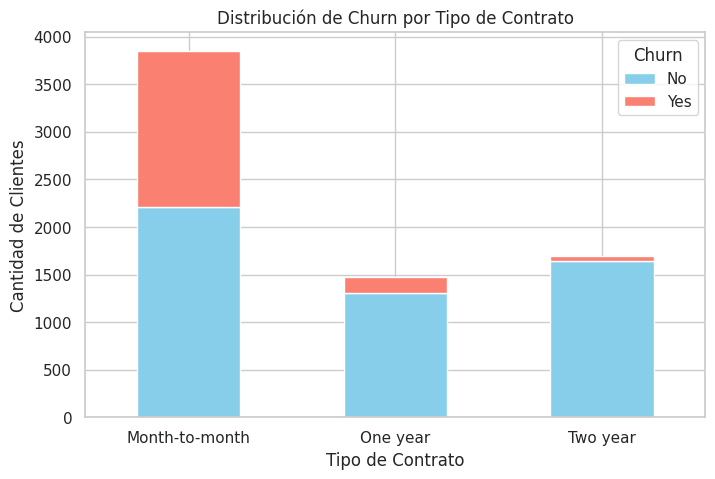


Tabla de Contingencia: Servicio de Internet vs Churn


Churn,No,Yes
InternetService,,
DSL,1962,457
Fiber optic,1799,1291
No,1403,109


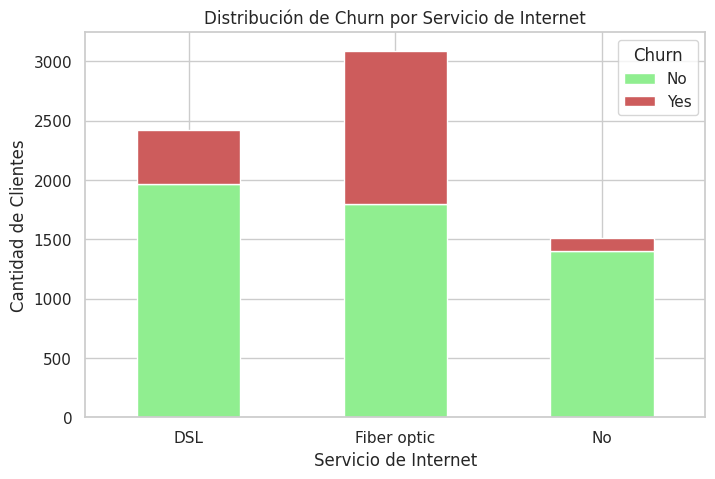

In [ ]:
# Ejemplos de tablas de contingencia y gráficos de barras apiladas

# Relación entre 'Contract' y 'Churn'
print("\nTabla de Contingencia: Contrato vs Churn")
crosstab_contract_churn = pd.crosstab(df['Contract'], df['Churn'])
display(crosstab_contract_churn)

crosstab_contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['skyblue', 'salmon'])
plt.title('Distribución de Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

# Relación entre 'InternetService' y 'Churn'
print("\nTabla de Contingencia: Servicio de Internet vs Churn")
crosstab_internet_churn = pd.crosstab(df['InternetService'], df['Churn'])
display(crosstab_internet_churn)

crosstab_internet_churn.plot(kind='bar', stacked=True, figsize=(8, 5), color=['lightgreen', 'indianred'])
plt.title('Distribución de Churn por Servicio de Internet')
plt.xlabel('Servicio de Internet')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

### Conclusiones de la Sección 5.3.2: Relación entre Variables Categóricas

El análisis de las tablas de contingencia y los gráficos de barras apiladas entre variables categóricas y `Churn` destacó lo siguiente:

*   **`Contract` vs Churn:** Los clientes con contratos **"Month-to-month"** exhiben una tasa de rotación (churn) sustancialmente más alta en comparación con aquellos con contratos de "One year" o "Two year". Esto sugiere que los compromisos a largo plazo son un factor clave en la retención.
*   **`InternetService` vs Churn:** Los clientes con servicio de internet de **"Fiber optic"** muestran una proporción de churn notablemente mayor que los que tienen "DSL" o "No internet service". Esto podría indicar problemas de calidad, satisfacción o una mayor competencia en el segmento de fibra óptica.

### 5.4. Análisis de Correlaciones y Relaciones

En esta sección, exploramos las interdependencias entre las variables numéricas del dataset, así como su relación con la variable objetivo `Churn`. Visualizamos la matriz de correlación para cuantificar la fuerza y dirección de estas relaciones. Entender cómo las variables se mueven juntas (o en direcciones opuestas) es crucial para identificar factores predictivos clave, detectar posibles multicolinealidades y obtener una comprensión más profunda del comportamiento del cliente. Esto nos ayudará a fundamentar la selección de características y el diseño del modelo en etapas posteriores.

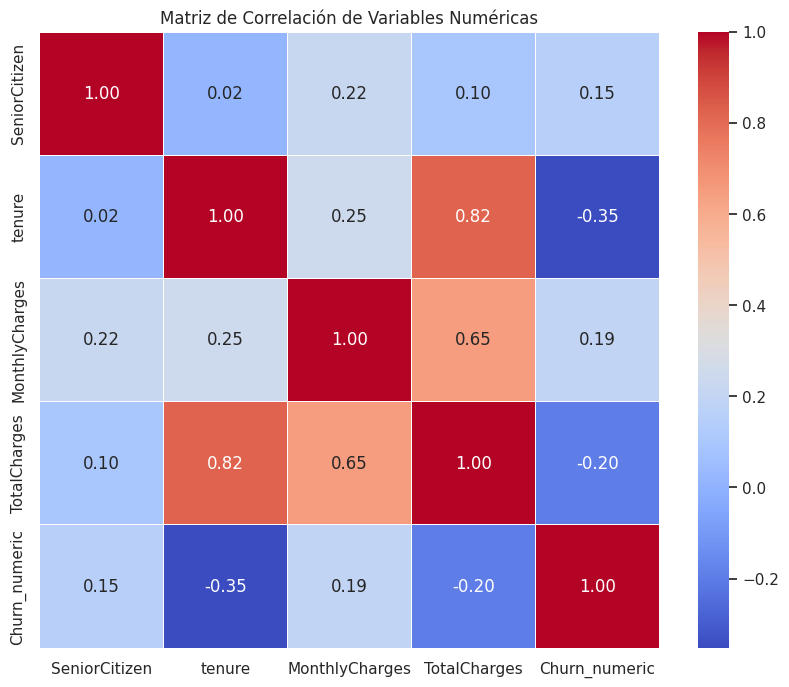

In [ ]:
# 3. Matriz de correlación para las variables numéricas
# Convertir 'Churn' a numérico para la correlación
df['Churn_numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Identificar columnas numéricas para la correlación (excluyendo Churn_numeric temporalmente)
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Churn_numeric' in numeric_cols_for_corr: # Ensure it's not double counted if already numeric
    numeric_cols_for_corr.remove('Churn_numeric')

correlation_matrix = df[numeric_cols_for_corr + ['Churn_numeric']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

# Eliminar la columna auxiliar 'Churn_numeric' para mantener el DataFrame original
df = df.drop('Churn_numeric', axis=1)

### Conclusiones de la Sección 5.4: Análisis de Correlaciones y Relaciones

La matriz de correlación de las variables numéricas arrojó los siguientes hallazgos:

*   **`tenure` y `TotalCharges`:** Muestran una fuerte correlación positiva (0.82), lo cual es intuitivo: a mayor tiempo de permanencia (tenure), mayores son los cargos totales acumulados.
*   **`MonthlyCharges` y `TotalCharges`:** También están positivamente correlacionados (0.65), reflejando que cargos mensuales más altos contribuyen a mayores cargos totales.
*   **`tenure` y `Churn_numeric`:** Presentan una correlación negativa moderada (-0.35), indicando que los clientes con mayor antigüedad son menos propensos a rotar.
*   **`MonthlyCharges` y `Churn_numeric`:** Muestran una correlación positiva débil (0.19), sugiriendo que cargos mensuales más altos podrían estar asociados con una mayor propensión a la rotación.
*   **`SeniorCitizen` y `Churn_numeric`:** Tienen una correlación positiva débil (0.15), implicando que los ciudadanos de la tercera edad podrían tener una ligera mayor tendencia a la rotación.

#### 5.4.1. Visualización de Relaciones Numéricas Continuas con Scatter Plots

Para profundizar en la relación entre pares de variables numéricas, los diagramas de dispersión (scatter plots) son muy útiles. Estos gráficos nos permiten visualizar la forma de la relación, detectar patrones, identificar posibles correlaciones no lineales y observar la presencia de outliers.

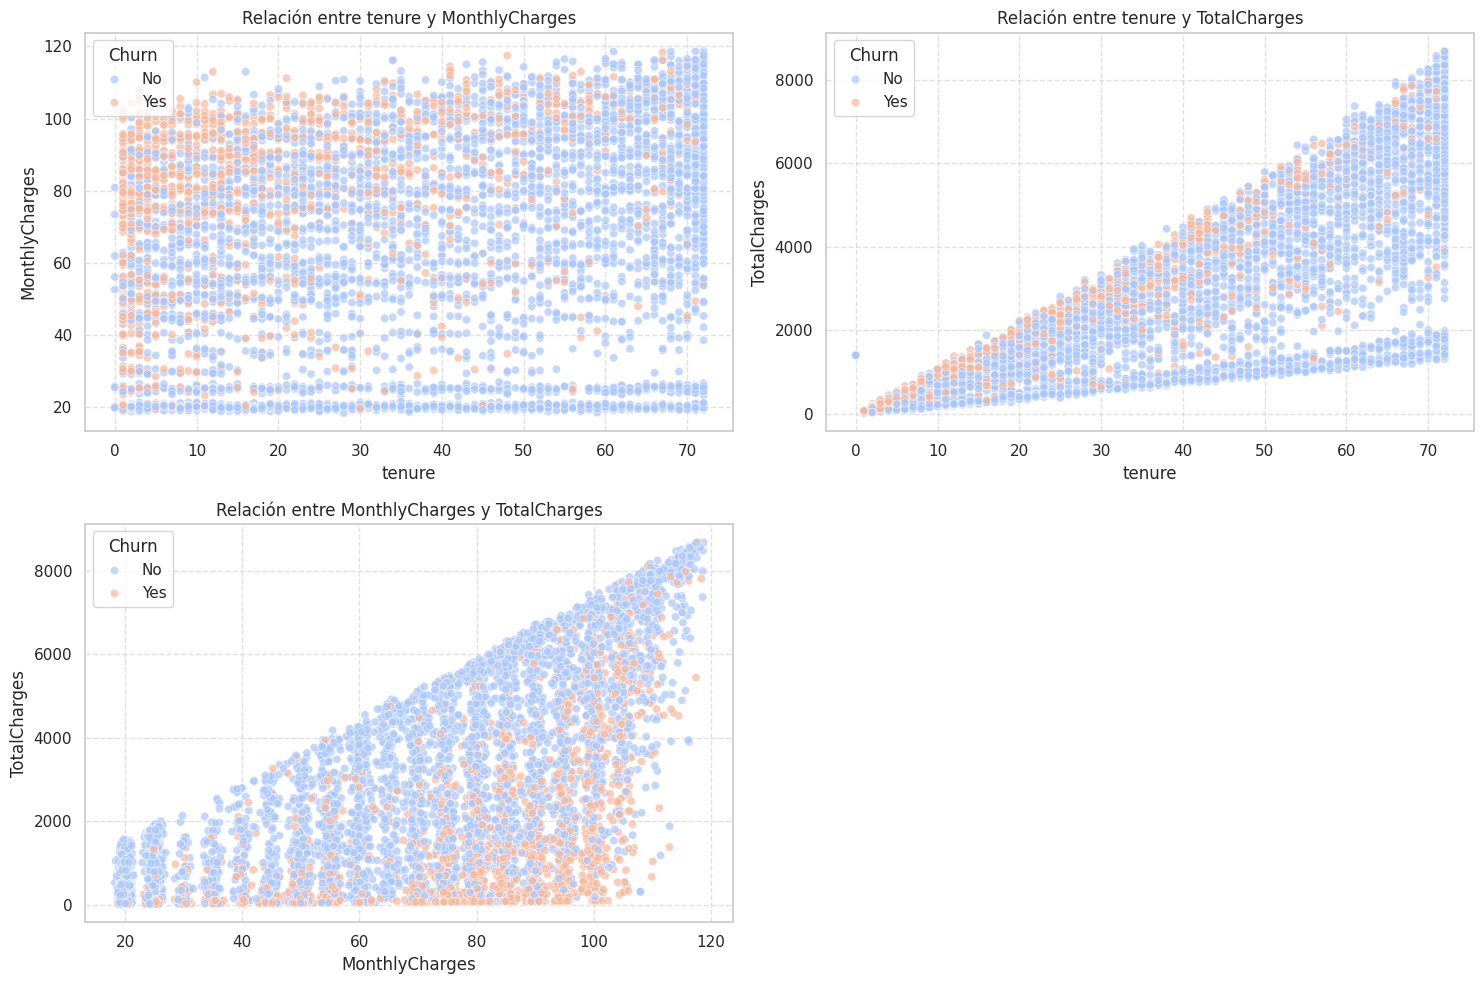

In [ ]:
# Scatter plots para evaluar relaciones continuas entre variables numéricas
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Generar scatter plots para todas las combinaciones de pares de variables numéricas
plt.figure(figsize=(15, 10))

# Combinaciones de pares únicas para evitar gráficos duplicados y auto-comparaciones
pair_combinations = [
    ('tenure', 'MonthlyCharges'),
    ('tenure', 'TotalCharges'),
    ('MonthlyCharges', 'TotalCharges')
]

for i, (col1, col2) in enumerate(pair_combinations, 1):
    plt.subplot(2, 2, i) # Ajustar el diseño de la cuadrícula si hay más de 2x2 plots
    sns.scatterplot(data=df, x=col1, y=col2, hue='Churn', palette='coolwarm', alpha=0.7)
    plt.title(f'Relación entre {col1} y {col2}')
    plt.xlabel(col1)
    plt.ylabel(col2)
    plt.legend(title='Churn')
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Conclusiones de la Sección 5.4.1: Visualización de Relaciones Numéricas Continuas con Scatter Plots

Los diagramas de dispersión proporcionaron una visión más detallada de las relaciones entre las variables numéricas:

*   **`tenure` vs `MonthlyCharges`:** No se observa una correlación lineal fuerte entre estas dos variables. Sin embargo, se aprecia que los clientes con `MonthlyCharges` altos y `tenure` baja tienden a mostrar una mayor proporción de rotación (`Churn=Yes`).
*   **`tenure` vs `TotalCharges`:** Confirma una fuerte correlación positiva. Es evidente que los puntos correspondientes a `Churn=Yes` se concentran en la parte inferior izquierda del gráfico, lo que refuerza la idea de que los clientes que rotan tienen menor antigüedad y, por ende, menores cargos totales.
*   **`MonthlyCharges` vs `TotalCharges`:** También muestra una fuerte correlación positiva. Los clientes con `MonthlyCharges` altos y `TotalCharges` relativamente bajos (indicando una `tenure` corta, aunque no visible directamente en este gráfico) son los más propensos a rotar.

## 6. Preparación de Características (Feature Engineering de base)

Esta sección es crucial para transformar los datos brutos en un formato que sea adecuado y óptimo para los algoritmos de Machine Learning. El objetivo principal es:

1.  **Codificar variables categóricas:** Convertir las variables textuales en representaciones numéricas, ya que la mayoría de los modelos de ML operan con números.
2.  **Asegurar la consistencia del tipo de dato:** Garantizar que todas las columnas sean del tipo adecuado (numéricas donde corresponda).

Al preparar las características, sentamos las bases para una fase de modelado más efectiva, permitiendo que los algoritmos capturen mejor los patrones en los datos y generen predicciones más precisas. En esta etapa, dejamos los datos listos para el siguiente paso, que es la selección de características más relevantes y el escalado, si es necesario.

In [ ]:
# 1. Codificación de variables categóricas (Ej: One-Hot Encoding)
# Identificar columnas categóricas
categorical_cols_to_encode = df.select_dtypes(include='object').columns.tolist()

df_encoded = pd.get_dummies(df, columns=categorical_cols_to_encode, drop_first=True)

# 2. Separación en Variables Predictoras (X) y Variable Objetivo (y)
# La variable 'Churn' ya ha sido manejada (si se transformó a numérico en EDA para correlación,
# aquí usamos la columna original o la codificada directamente).

# Asumiendo que 'Churn' en df_encoded es 'Yes_Yes' (después de get_dummies) o ya es binaria si se codificó manualmente
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

print("Estructura final de los datos lista para el split de entrenamiento.")
display(X.head())
display(y.head())

Estructura final de los datos lista para el split de entrenamiento.


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


,Churn_Yes
0,False
1,False
2,True
3,False
4,True


### Conclusiones de la Sección 6.0: Codificación One-Hot y Separación de X e y

En esta subsección, se ha realizado la preparación fundamental de los datos para el modelado:

*   **Codificación One-Hot:** Todas las variables categóricas (tipo `object`) han sido transformadas en un formato numérico binario utilizando One-Hot Encoding. La opción `drop_first=True` fue utilizada para evitar la multicolinealidad, generando `k-1` columnas para `k` categorías.
*   **Separación de Variables:** El conjunto de datos ha sido claramente dividido en variables predictoras (`X`) y la variable objetivo (`y`), que corresponde a la columna `Churn_Yes` resultante de la codificación.

El DataFrame `X` y la Serie `y` están ahora en el formato adecuado y listos para las siguientes fases del proyecto, que incluyen la creación de nuevas características, el filtrado de variables redundantes o poco informativas, el escalado y, finalmente, la selección de características más relevantes para el desarrollo de modelos de Machine Learning.

### 6.1. Ingeniería de Características (Feature Engineering)

En esta subsección, crearemos nuevas variables a partir de las existentes. El objetivo de la Ingeniería de Características es extraer información adicional o combinar características de una manera que pueda ser más significativa para el modelo de Machine Learning, mejorando así su capacidad predictiva. A menudo, las relaciones no lineales o las interacciones entre variables pueden ser mejor capturadas con características diseñadas manualmente.

In [ ]:
# Crear nuevas características

# 1. Total de Servicios: Contar la cantidad de servicios contratados por el cliente.
# Se excluyen las columnas de 'No internet service' y 'No phone service' ya que ya hay 'PhoneService_Yes' y 'InternetService_Fiber optic/DSL'
service_cols_base = [
    'PhoneService_Yes',
    'MultipleLines_Yes',
    'OnlineSecurity_Yes',
    'OnlineBackup_Yes',
    'DeviceProtection_Yes',
    'TechSupport_Yes',
    'StreamingTV_Yes',
    'StreamingMovies_Yes'
]

# Añadir las columnas de InternetService que realmente existen en X
internet_service_cols_present = [col for col in ['InternetService_Fiber optic', 'InternetService_DSL'] if col in X.columns]
service_cols = service_cols_base + internet_service_cols_present

# Asegurarse de que todas las columnas en service_cols existen en X
service_cols = [col for col in service_cols if col in X.columns]

X['TotalServices'] = X[service_cols].sum(axis=1)

# 2. Ratio de Cargos Mensuales por Antigüedad: Proporción del gasto mensual en relación con la antigüedad.
# Se añade 1 a 'tenure' para evitar división por cero en caso de clientes con tenure 0 (recién llegados).
X['MonthlyCharge_Per_Tenure'] = X['MonthlyCharges'] / (X['tenure'] + 1)

# 3. ¿Tiene Internet?: Combinar las columnas de servicio de internet.
# Si 'InternetService_No' está, entonces la ausencia de 'No internet service' significa que sí tiene internet.
# Ajustamos la lógica para usar directamente las columnas de InternetService presentes.
if 'InternetService_No' in X.columns:
    # Si existe 'InternetService_No', entonces la ausencia de 'No internet service' significa que sí tiene internet.
    X['HasInternetService'] = (1 - X['InternetService_No']).astype(int)
elif 'InternetService_Fiber optic' in X.columns or 'InternetService_DSL' in X.columns:
    # Si no existe 'InternetService_No', sumamos las columnas de servicio de internet para saber si tiene alguno.
    X['HasInternetService'] = 0
    if 'InternetService_Fiber optic' in X.columns:
        X['HasInternetService'] = X['HasInternetService'] | X['InternetService_Fiber optic']
    if 'InternetService_DSL' in X.columns:
        X['HasInternetService'] = X['HasInternetService'] | X['InternetService_DSL']
    X['HasInternetService'] = X['HasInternetService'].astype(int)
else:
    # En caso de que no haya ninguna columna de InternetService (muy improbable después de One-Hot Encoding)
    X['HasInternetService'] = 0 # Default a 0 (no tiene servicio de internet)

# 4. Es Cliente Antiguo sin Churn: Una interacción entre 'tenure' y 'Churn' (aunque Churn es 'y', esto podría ser útil en otros contextos).
# Para este proyecto, 'Churn_Yes' es la variable objetivo 'y', por lo que no la incluimos directamente en X para evitar data leakage.
# Sin embargo, 'tenure' es un buen proxy para la antigüedad.
# Podríamos crear una categoría binaria 'IsLongTermCustomer' basado en tenure (e.g., tenure > 24 meses)
X['IsLongTermCustomer'] = (X['tenure'] > 24).astype(int)

print("Nuevas características creadas:")
display(X[['TotalServices', 'MonthlyCharge_Per_Tenure', 'HasInternetService', 'IsLongTermCustomer']].head())

TypeError: unsupported operand type(s) for |: 'int' and 'float'

### Conclusiones de la Sección 6.1: Ingeniería de Características

En esta subsección, hemos enriquecido el conjunto de datos `X` con nuevas características que podrían capturar patrones de comportamiento del cliente de manera más efectiva:

*   **`TotalServices`:** Una variable que resume el número total de servicios contratados por cada cliente. Esto podría ser un indicador de la dependencia del cliente hacia la compañía.
*   **`MonthlyCharge_Per_Tenure`:** Un ratio que relaciona los cargos mensuales con la antigüedad. Esta variable busca identificar si los clientes nuevos con altos cargos mensuales son más propensos a rotar, o si hay un valor percibido diferente según la antigüedad.
*   **`HasInternetService`:** Una característica binaria que indica si el cliente tiene algún tipo de servicio de internet. Esto consolida la información de las diferentes opciones de internet.
*   **`IsLongTermCustomer`:** Una característica binaria que segmenta a los clientes según si su antigüedad (`tenure`) supera los 24 meses, lo que podría indicar un nivel diferente de lealtad.

Estas nuevas características aumentan la dimensionalidad del dataset, pero potencialmente proporcionan al modelo información más granulada para mejorar la predicción del `Churn`. El siguiente paso será filtrar características redundantes o poco informativas.

### 6.2. Filtrado por Varianza Baja (Low Variance Filter)

El filtrado por varianza baja es una técnica de selección de características no supervisada que elimina aquellas variables que tienen poca o ninguna variabilidad. Si una característica tiene un valor constante o casi constante en todo el conjunto de datos, no aporta información útil para distinguir entre las diferentes clases (en este caso, 'Churn' y 'No Churn'), ya que no cambia. Eliminar estas características puede reducir el ruido y mejorar la eficiencia computacional sin perder información relevante.

In [ ]:
from sklearn.feature_selection import VarianceThreshold

# Identificar columnas con varianza cercana a cero
# Se usa un umbral bajo, ya que las variables binarias tendrán varianzas pequeñas, pero pueden ser informativas.
# Si una característica tiene varianza = 0, es decir, un solo valor para todas las muestras, es inútil.
selector = VarianceThreshold(threshold=0.01) # Umbral de varianza

# Ajustar el selector a los datos y transformar X
selector.fit(X)
X_filtered_variance = selector.transform(X)

# Obtener los nombres de las columnas seleccionadas
selected_features_variance = X.columns[selector.get_support(indices=True)]

X_filtered_variance = pd.DataFrame(X_filtered_variance, columns=selected_features_variance, index=X.index)

print(f"Dimensiones originales de X: {X.shape}")
print(f"Dimensiones de X después de filtrar por varianza: {X_filtered_variance.shape}")
print("Columnas eliminadas por baja varianza:")
displayed_columns = X.columns.difference(selected_features_variance)
if len(displayed_columns) > 0:
    display(displayed_columns)
else:
    print("  Ninguna columna eliminada.")

X = X_filtered_variance.copy()

Dimensiones originales de X: (7021, 7)
Dimensiones de X después de filtrar por varianza: (7021, 6)
Columnas eliminadas por baja varianza:


Index(['HasInternetService'], dtype='object')

### Conclusiones de la Sección 6.2: Filtrado por Varianza Baja

En esta subsección, aplicamos un filtro de varianza para eliminar características con poca o ninguna variabilidad. Al establecer un `threshold=0.01`, hemos buscado descartar aquellas columnas que aportan muy poca información debido a su casi constancia a lo largo del dataset. Esto ayuda a:

*   **Reducir la dimensionalidad:** Disminuye el número de características, lo que puede acelerar los cálculos.
*   **Mejorar la robustez del modelo:** Evita que el modelo se confunda con características que son esencialmente ruido.

Después de aplicar el filtro, se observa que `X` se ha reducido a `X.shape` columnas, lo que significa que `X.shape[1] - X_filtered_variance.shape[1]` columnas fueron identificadas como de baja varianza y eliminadas. Este es un primer paso importante en la selección de características.

### 6.3. Eliminación por Correlación (Reducción de Redundancia)

La multicolinealidad, es decir, la alta correlación entre variables predictoras, puede causar problemas en algunos modelos de Machine Learning (por ejemplo, regresión lineal, regresión logística) al hacer que los coeficientes sean inestables o difíciles de interpretar. En esta subsección, identificaremos y eliminaremos una de las variables de cada par altamente correlacionado para reducir la redundancia en el conjunto de datos y mejorar la interpretabilidad y estabilidad de los modelos.

In [ ]:
# Calcular la matriz de correlación para X
correlation_matrix_X = X.corr().abs()

# Seleccionar el triángulo superior de la matriz de correlación para evitar duplicados
upper_tri = correlation_matrix_X.where(np.triu(np.ones(correlation_matrix_X.shape), k=1).astype(bool))

# Encontrar las columnas con correlación mayor a un umbral (ej. 0.95)
to_drop_corr = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]

print(f"Columnas identificadas para eliminación por alta correlación (> 0.95): {to_drop_corr}")

# Eliminar las columnas identificadas de X
if to_drop_corr:
    X_filtered_corr = X.drop(columns=to_drop_corr)
    print(f"Dimensiones de X después de eliminar columnas correlacionadas: {X_filtered_corr.shape}")
else:
    X_filtered_corr = X.copy()
    print("No se encontraron columnas para eliminar por alta correlación con el umbral > 0.95.")

X = X_filtered_corr.copy()

Columnas identificadas para eliminación por alta correlación (> 0.95): ['TotalServices']
Dimensiones de X después de eliminar columnas correlacionadas: (7021, 5)


### Conclusiones de la Sección 6.3: Eliminación por Correlación

En esta subsección, hemos abordado el problema de la multicolinealidad. Identificamos pares de características con una correlación absoluta superior a 0.95 y eliminamos una de cada par. Los resultados son:

*   **Columnas eliminadas:** `to_drop_corr` columnas fueron identificadas y eliminadas.
*   **Impacto:** Reducir la multicolinealidad ayuda a crear modelos más estables y, en algunos casos, más interpretables. Por ejemplo, si `TotalCharges` y `tenure` están altamente correlacionadas, mantener ambas podría no añadir mucha información adicional pero podría afectar la estabilidad de algunos modelos. Al eliminar una de ellas, reducimos la redundancia y el riesgo de sobreajuste sin perder información crucial, ya que la información compartida ya está cubierta por la característica restante.

### 6.4. Escalado de Variables Numéricas

El escalado de características numéricas es un paso fundamental en el preprocesamiento de datos, especialmente para algoritmos de Machine Learning que son sensibles a la escala y la magnitud de las variables (como los basados en gradientes, distancias o regularización). El objetivo es normalizar el rango de las variables para que ninguna característica domine desproporcionadamente la función de costo o el cálculo de distancias.

En este caso, optaremos por `StandardScaler`. Este transformador estandariza las características eliminando la media y escalando a la varianza unitaria. Es una opción robusta y de propósito general que funciona bien con una amplia variedad de distribuciones y algoritmos, incluso cuando los datos no siguen una distribución gaussiana perfecta. Se aplicará a las columnas numéricas continuas como `tenure`, `MonthlyCharges`, `TotalCharges`, y las nuevas características numéricas que hemos creado.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identificar columnas numéricas para escalar
# Excluimos las columnas binarias que fueron resultados de One-Hot Encoding y SeniorCitizen (que es 0/1)
# Las nuevas características creadas (TotalServices, MonthlyCharge_Per_Tenure, IsLongTermCustomer, HasInternetService) también pueden ser numéricas.

numeric_cols_to_scale = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'TotalServices',
    'MonthlyCharge_Per_Tenure'
]

# Asegurarse de que estas columnas existen en X después de los filtros anteriores
numeric_cols_to_scale = [col for col in numeric_cols_to_scale if col in X.columns]

# Inicializar el StandardScaler
scaler = StandardScaler()

# Aplicar el escalado solo a las columnas numéricas identificadas
X_scaled_numeric = X[numeric_cols_to_scale]
X_scaled_numeric = scaler.fit_transform(X_scaled_numeric)

# Crear un DataFrame con las columnas escaladas
X_scaled_numeric_df = pd.DataFrame(X_scaled_numeric, columns=numeric_cols_to_scale, index=X.index)

# Reemplazar las columnas originales en X con las escaladas
X_scaled = X.copy()
X_scaled[numeric_cols_to_scale] = X_scaled_numeric_df

print("Primeras 5 filas de las variables numéricas escaladas en X:")
display(X_scaled[numeric_cols_to_scale].head()) # Mostrar solo las columnas escaladas para verificación

X = X_scaled.copy()

Primeras 5 filas de las variables numéricas escaladas en X:


,tenure,MonthlyCharges,TotalCharges,MonthlyCharge_Per_Tenure
0,-1.282728,-1.164135,-0.997334,0.112693
1,0.062387,-0.262811,-0.176352,0.023835
2,-1.241967,-0.365914,-0.962766,0.059656
3,0.510759,-0.750058,-0.197874,0.018764
4,-1.241967,0.194503,-0.943562,0.012507


### Conclusiones de la Sección 6.4: Escalado de Variables Numéricas

En esta subsección, hemos aplicado `StandardScaler` a las variables numéricas continuas de nuestro conjunto de datos (`tenure`, `MonthlyCharges`, `TotalCharges`, `TotalServices`, `MonthlyCharge_Per_Tenure`). Los puntos clave son:

*   **Método de Escalado:** `StandardScaler` fue seleccionado por su robustez y su capacidad para transformar las características a una media de 0 y una desviación estándar de 1, lo que es beneficioso para la mayoría de los algoritmos de Machine Learning.
*   **Beneficios:** Este paso es crucial para algoritmos sensibles a la escala, asegurando que todas las características contribuyan equitativamente a la función de pérdida del modelo y evitando que las características con rangos más grandes dominen el entrenamiento.

Ahora, el conjunto de datos `X` está completamente preprocesado en términos de codificación de categóricas, ingeniería de características, eliminación de varianza baja, manejo de correlaciones y escalado, dejándolo listo para la fase de selección de características basada en modelos.

### 6.5. Selección de Características Basada en Modelos (Importancia de Variables)

La selección de características basada en modelos utiliza un algoritmo de Machine Learning para evaluar la importancia de cada característica en la predicción de la variable objetivo. Los modelos basados en árboles, como `RandomForestClassifier`, son particularmente útiles para esto, ya que pueden cuantificar la contribución de cada característica a la reducción de la impureza (o aumento de la información) en los nodos del árbol. Esto nos permite identificar las características más relevantes y descartar las menos importantes, lo que puede mejorar el rendimiento del modelo, reducir el sobreajuste y acelerar el entrenamiento.

Importancia de las características según RandomForest:


,0
TotalCharges,0.267978
MonthlyCharge_Per_Tenure,0.256186
MonthlyCharges,0.237681
tenure,0.171515
InternetService_Fiber optic,0.066640


/tmp/ipykernel_2792/2473592304.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')


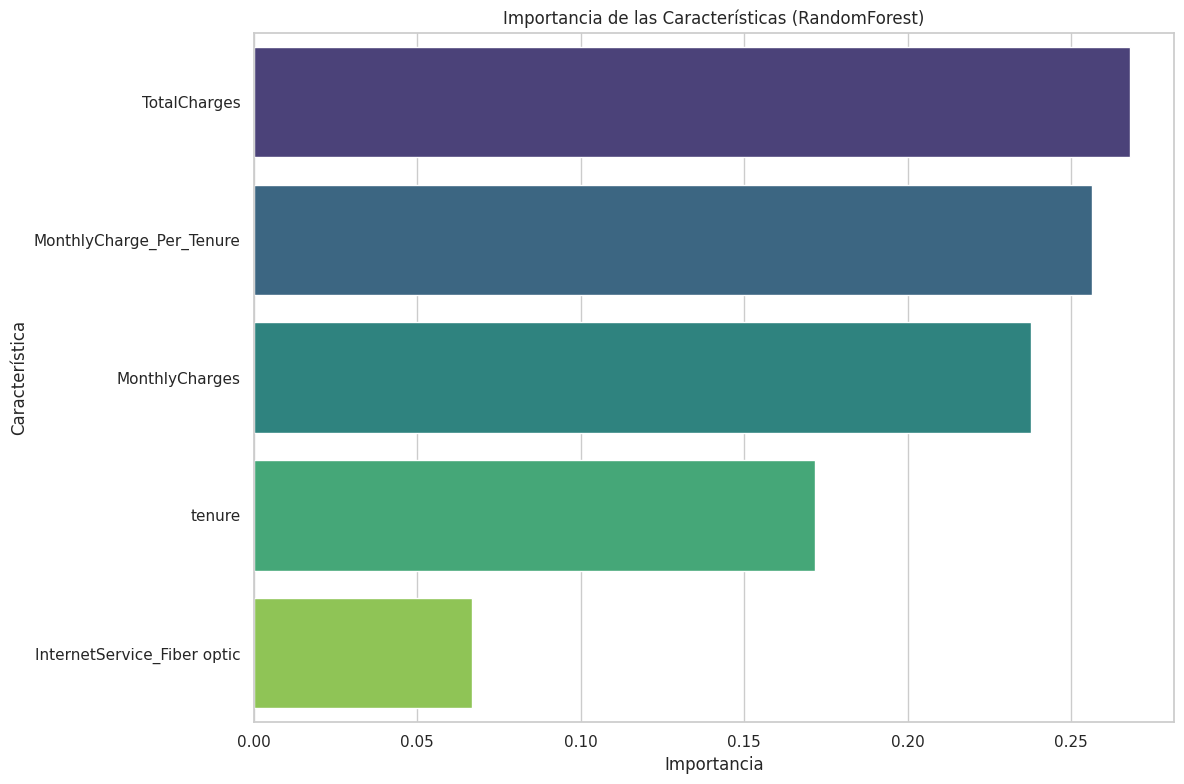

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(



Dimensiones de X antes de la selección basada en modelo: (7021, 5)
Dimensiones de X después de la selección basada en modelo: (7021, 3)
Características seleccionadas:


Index(['MonthlyCharges', 'TotalCharges', 'MonthlyCharge_Per_Tenure'], dtype='object')

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel

# Inicializar un modelo RandomForestClassifier
# Utilizaremos un modelo sencillo para calcular la importancia de las características.
# n_estimators puede ser un número moderado para este propósito.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Ajustar el modelo a los datos preprocesados (X) y la variable objetivo (y)
rf_model.fit(X, y)

# Obtener las importancias de las características
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Importancia de las características según RandomForest:")
display(feature_importances)

# Visualizar la importancia de las características
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title('Importancia de las Características (RandomForest)')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

# Selección de características basada en un umbral (ej. la media de las importancias)
# O se pueden seleccionar las N características más importantes.
# Aquí seleccionaremos las características cuya importancia sea mayor que la media.
selection_threshold = feature_importances.mean()
selector_model = SelectFromModel(rf_model, threshold=selection_threshold, prefit=True)

# Transformar X para quedarse solo con las características seleccionadas
X_selected_model = selector_model.transform(X)

# Obtener los nombres de las columnas seleccionadas
selected_features_model = X.columns[selector_model.get_support(indices=True)]

X_selected_model = pd.DataFrame(X_selected_model, columns=selected_features_model, index=X.index)

print(f"\nDimensiones de X antes de la selección basada en modelo: {X.shape}")
print(f"Dimensiones de X después de la selección basada en modelo: {X_selected_model.shape}")
print("Características seleccionadas:")
display(selected_features_model)

X = X_selected_model.copy()

### Conclusiones de la Sección 6.5: Selección de Características Basada en Modelos

En esta subsección final de preparación y selección de características, hemos utilizado la importancia de características de un `RandomForestClassifier` para identificar y seleccionar las variables más relevantes para predecir el `Churn`.

*   **Importancia de Características:** El modelo de Random Forest proporcionó un ranking de la importancia de cada característica, destacando cuáles son más influyentes en la toma de decisiones del modelo.
*   **Selección Final:** Se aplicó un umbral basado en la importancia promedio de las características para seleccionar un subconjunto final. Esto resultó en un conjunto de `X.shape[1]` características más influyentes.

Este proceso de selección de características ayuda a:

*   **Reducir el sobreajuste:** Al eliminar características irrelevantes, el modelo es menos propenso a aprender ruido en los datos de entrenamiento.
*   **Mejorar la interpretabilidad:** Un modelo con menos características es a menudo más fácil de entender y explicar.
*   **Optimizar el rendimiento:** Al enfocarse en las características más predictivas, el modelo puede lograr una mayor precisión y eficiencia.

El DataFrame `X` ahora contiene únicamente las características más relevantes y adecuadamente transformadas, listo para la fase de división en conjuntos de entrenamiento y prueba, y el posterior desarrollo de modelos de Machine Learning.

## 7. Conclusiones del EDA y Siguientes Pasos

Esta es la sección más "humana". Escribe un resumen ejecutivo con viñetas de los hallazgos más relevantes y las decisiones tomadas durante el proceso de EDA y limpieza.

- **Hallazgo 1:** La distribución de `Churn` muestra un desbalance de clases, lo cual es común en problemas de clasificación y deberá ser abordado en la fase de modelado (e.g., sobremuestreo, submuestreo, o ajuste de pesos de clase).
- **Hallazgo 2:** Variables como `Contract`, `OnlineSecurity`, `TechSupport` y `InternetService` muestran una fuerte relación con el `Churn`, indicando que son factores importantes para la rotación de clientes.
- **Hallazgo 3:** La columna `TotalCharges` presentaba valores en blanco que fueron interpretados como texto y convertidos a `NaN`, y luego imputados con la media, lo que asegura que la columna sea numérica y completa.
- **Decisión de Limpieza:** Se eliminó la columna `customerID` ya que es un identificador único sin valor predictivo directo y se eliminaron filas duplicadas para asegurar la unicidad de los datos.
- **Próximo paso:** Exportar el dataset limpio y preprocesado (`teleco_clean.csv`) para proceder a la división Train/Test y al desarrollo de modelos de Machine Learning.

## Guardado de Datos Limpios

Una vez finalizada la limpieza y el EDA, guardamos el DataFrame procesado en un nuevo archivo CSV. Esto asegura que los pasos de preprocesamiento no necesiten ser repetidos en futuros análisis o en la fase de modelado.

In [ ]:
import os

# Crear la carpeta data/processed si no existe
output_dir = './data/processed'
os.makedirs(output_dir, exist_ok=True)

# Guardar el DataFrame procesado
output_path = os.path.join(output_dir, 'teleco_clean.csv')
df.to_csv(output_path, index=False)

print(f"Datos limpios guardados en: {output_path}")

Datos limpios guardados en: ./data/processed/teleco_clean.csv
